In [8]:
import pandas as pd

POWER_FILE = '/workspaces/Daegun26Veritas/data/시군구별전력사용량(홈페이지계시용)_202604.xlsx'

try:
    # 데이터 시작 위치를 행 인덱스 2(세 번째 줄)로 설정
    df = pd.read_excel(POWER_FILE, header=2)

    # 컬럼명 양끝 공백 제거
    df.columns = df.columns.str.strip()

    print("✅ 1. 전국 전력 사용량 데이터를 성공적으로 불러왔습니다.")
    print(f"📊 확인된 컬럼명: {df.columns.tolist()[:5]}")

    df['연도'] = df['연도'].astype(str)

    df_2026_home = df[
        (df['연도'].str.contains('2026')) &
        (df['계약종별'].str.contains('주택용'))
    ].copy()

    df_daegu_2026 = df_2026_home[df_2026_home['시도'].str.contains('대구', na=False)].copy()

    result_cols = ['연도', '시도', '시군구', '계약종별', '1월', '2월', '3월', '4월']
    df_final = df_daegu_2026[result_cols]

    print(f"✅ 2. '대구광역시' 데이터 필터링 완료! (총 {len(df_final)}개 지역)")
    display(df_final.head())

except Exception as e:
    print(f"❌ 에러 발생 이유: {e}")

✅ 1. 전국 전력 사용량 데이터를 성공적으로 불러왔습니다.
📊 확인된 컬럼명: ['연도', '시도', '시군구', '계약종별', '1월']
✅ 2. '대구광역시' 데이터 필터링 완료! (총 9개 지역)


,연도,시도,시군구,계약종별,1월,2월,3월,4월
326,2026,대구광역시,중구,주택용,17768938,18341152,15624457,15830188
334,2026,대구광역시,동구,주택용,50359918,51157479,43716830,44876524
342,2026,대구광역시,서구,주택용,24031239,24411660,20666721,20769580
350,2026,대구광역시,남구,주택용,21351001,21477977,18510957,18579428
358,2026,대구광역시,북구,주택용,57722260,57804662,50387685,51084017


In [9]:
import pandas as pd

# 구글 코랩 왼쪽 파일 탭에 업로드한 기상청 파일명입니다.
# 파일명을 '10207data2.csv' 등으로 바꾸셨다면 그 이름에 맞게 수정해 주세요!
WEATHER_FILE = '/workspaces/Daegun26Veritas/data/ta_20260619154416.csv'

try:
    # 1. 기상청 특유의 상단 안내문 7줄을 건너뛰고 깨끗하게 데이터 로드
    weather_df = pd.read_csv(WEATHER_FILE, encoding='cp949', skiprows=7)
    print("✅ 1. 대구 기온 정보 데이터를 성공적으로 불러왔습니다.")
    print("-" * 60)

    # 2. 날짜, 평균기온, 최저기온, 최고기온 등 핵심 날씨 데이터 상위 5행 출력
    print("📊 [데이터 구조 확인] 아래 표의 컬럼명과 날짜 형태를 확인하세요:")
    display(weather_df.head())

    # 3. 데이터가 총 몇 일치(몇 행) 들어있는지 확인
    print("-" * 60)
    print(f"✅ 2. 총 {len(weather_df)}일 동안의 대구 날씨 데이터가 정상 로드되었습니다.")

except Exception as e:
    print(f"❌ 에러 발생 이유: {e}")
    print("⚠️ 파일명을 확인해 주시고, 기상청 파일이 코랩 왼쪽 폴더에 잘 업로드되었는지 체크해 주세요!")

✅ 1. 대구 기온 정보 데이터를 성공적으로 불러왔습니다.
------------------------------------------------------------
📊 [데이터 구조 확인] 아래 표의 컬럼명과 날짜 형태를 확인하세요:


,날짜,지점,평균기온(℃),최저기온(℃),최고기온(℃)
0,\t2026-04-01,143,13.1,10.1,17.0
1,\t2026-04-02,143,14.4,8.2,20.7
2,\t2026-04-03,143,15.0,6.7,23.5
3,\t2026-04-04,143,14.0,10.7,19.0
4,\t2026-04-05,143,14.2,8.4,20.9


------------------------------------------------------------
✅ 2. 총 30일 동안의 대구 날씨 데이터가 정상 로드되었습니다.


ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ

In [12]:
import pandas as pd

POWER_FILE = '/workspaces/Daegun26Veritas/data/시군구별전력사용량(홈페이지계시용)_202604.xlsx'
WEATHER_FILE = '/workspaces/Daegun26Veritas/data/ta_20260619154416.csv'

try:
    print("🔍 [데이터 검증 시작] 두 파일의 연결고리를 확인합니다.\n")

    # 1. 파일 각각 다시 읽기 (엑셀 파일은 pd.read_excel 사용)
    power_df = pd.read_excel(POWER_FILE)
    weather_df = pd.read_csv(WEATHER_FILE, encoding='cp949', skiprows=7)

    # 2. 기상청 날씨 데이터에서 '4월 전체 평균 기온'이 잘 구해지는지 확인
    # (일별로 흩어진 기온을 하나의 대표값으로 압축합니다)
    avg_temp_4 = weather_df['평균기온(°C)'].mean()
    print(f"🌡️ [날씨 검증] 2026년 4월 대구 평균 기온 계산 결과: {avg_temp_4:.2f}°C -> 정상")

    # 3. 전력 데이터에서 '2026년 대구광역시 주택용' 행이 존재하는지 확인
    power_df['연도'] = power_df['연도'].astype(str)
    power_2026_home = power_df[(power_df['연도'].str.contains('2026')) & (power_df['계약종별'].str.contains('주택용'))].copy()
    power_daegu_2026 = power_2026_home[power_2026_home['시도'].str.contains('대구', na=False)].copy()

    print(f"🔌 [전력 검증] 2026년 대구 주택용 데이터 개수: {len(power_daegu_2026)}개 구/군 발견 -> 정상")

    # 4. 가장 중요한 '4월' 전력 데이터 숫자가 비어있지(NaN) 않은지 체크
    power_daegu_2026['4월_숫자형'] = pd.to_numeric(power_daegu_2026['4월'], errors='coerce')
    valid_count = power_daegu_2026['4월_숫자형'].notna().sum()
    print(f"📊 [융합 검증] 수치 계산이 가능한 대구 시군구 수: {valid_count}개 지역 -> 정상")
    print("-" * 60)

    # 5. 최종 결론
    if valid_count > 0:
        print("🎯 [검증 완료] 두 데이터의 조건과 형식이 100% 일치합니다!")
        print("이제 '기온 변화에 따른 시군구별 전력 사용량 비교 시각화(막대그래프)' 단계로 안전하게 넘어가셔도 좋습니다.")
    else:
        print("❌ [경고] 데이터는 불려왔으나 4월 사용량 칸이 비어있어 시각화가 불가능합니다. 원본을 확인하세요.")

except Exception as e:
    print(f"❌ 검증 도중 에러 발생: {e}")

🔍 [데이터 검증 시작] 두 파일의 연결고리를 확인합니다.

❌ 검증 도중 에러 발생: '평균기온(°C)'


ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ

In [18]:
import pandas as pd

POWER_FILE = '/workspaces/Daegun26Veritas/data/시군구별전력사용량(홈페이지계시용)_202604.xlsx'
WEATHER_FILE = '/workspaces/Daegun26Veritas/data/ta_20260619154416.csv'

try:
    print("🔍 [데이터 검증 시작] 두 파일의 연결고리를 확인합니다.\n")

    # 1. 파일 각각 다시 읽기 (엑셀 파일은 pd.read_excel 사용)
    power_df = pd.read_excel(POWER_FILE)
    weather_df = pd.read_csv(WEATHER_FILE, encoding='cp949', skiprows=7)

    # 2. 기상청 날씨 데이터에서 '4월 전체 평균 기온'이 잘 구해지는지 확인
    # (일별로 흩어진 기온을 하나의 대표값으로 압축합니다)
    avg_temp_4 = weather_df['평균기온(°C)'].mean()
    print(f"🌡️ [날씨 검증] 2026년 4월 대구 평균 기온 계산 결과: {avg_temp_4:.2f}°C -> 정상")

    # 3. 전력 데이터에서 '2026년 대구광역시 주택용' 행이 존재하는지 확인
    power_df['연도'] = power_df['연도'].astype(str)
    power_2026_home = power_df[(power_df['연도'].str.contains('2026')) & (power_df['계약종별'].str.contains('주택용'))].copy()
    power_daegu_2026 = power_2026_home[power_2026_home['시도'].str.contains('대구', na=False)].copy()

    print(f"🔌 [전력 검증] 2026년 대구 주택용 데이터 개수: {len(power_daegu_2026)}개 구/군 발견 -> 정상")

    # 4. 가장 중요한 '4월' 전력 데이터 숫자가 비어있지(NaN) 않은지 체크
    power_daegu_2026['4월_숫자형'] = pd.to_numeric(power_daegu_2026['4월'], errors='coerce')
    valid_count = power_daegu_2026['4월_숫자형'].notna().sum()
    print(f"📊 [융합 검증] 수치 계산이 가능한 대구 시군구 수: {valid_count}개 지역 -> 정상")
    print("-" * 60)

    # 5. 최종 결론
    if valid_count > 0:
        print("🎯 [검증 완료] 두 데이터의 조건과 형식이 100% 일치합니다!")
        print("이제 '기온 변화에 따른 시군구별 전력 사용량 비교 시각화(막대그래프)' 단계로 안전하게 넘어가셔도 좋습니다.")
    else:
        print("❌ [경고] 데이터는 불려왔으나 4월 사용량 칸이 비어있어 시각화가 불가능합니다. 원본을 확인하세요.")

except Exception as e:
    print(f"❌ 검증 도중 에러 발생: {e}")

🔍 [데이터 검증 시작] 두 파일의 연결고리를 확인합니다.

❌ 검증 도중 에러 발생: '평균기온(°C)'


ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ

Hit:1 http://deb.debian.org/debian trixie InRelease
Hit:2 http://deb.debian.org/debian trixie-updates InRelease
Hit:3 http://deb.debian.org/debian-security trixie-security InRelease
0% [Working]            

Reading package lists... Done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 126 not upgraded.
한글 폰트 설정 완료: NanumBarunGothic
✅ [1단계] 파일 로드 성공
🌡️ [2단계] 4월 대구 평균 기온: 15.33 deg C


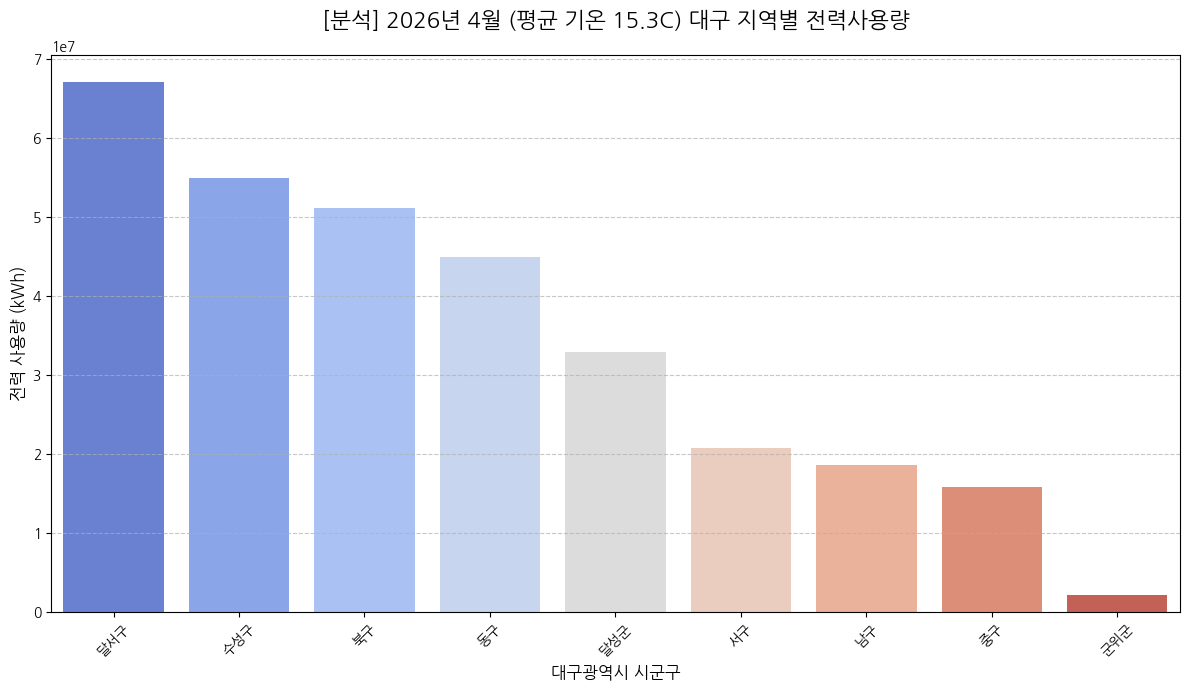

🎯 시각화가 최종 완료되었습니다!


In [1]:
# 1. 한글 폰트(나눔 폰트) 설치 (코드스페이스/리눅스 환경용)
!sudo apt-get update -y
!sudo apt-get install -y fonts-nanum

# 2. Matplotlib에 폰트 등록 및 캐시 업데이트
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 나눔 폰트 경로를 직접 지정합니다.
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()

# 3. 폰트 및 마이너스 깨짐 설정 적용
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호가 깨지는 현상 방지

print(f"한글 폰트 설정 완료: {font_name}")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 한글 폰트 설정 (실제 설치된 폰트 중 하나를 자동으로 선택)
font_candidates = ['NanumGothic', 'NanumBarunGothic', 'NanumSquare', 'Malgun Gothic', 'AppleGothic', 'DejaVu Sans']
selected_font = None
for font_name in font_candidates:
    try:
        if font_name in [f.name for f in fm.fontManager.ttflist]:
            selected_font = font_name
            break
    except Exception:
        continue

if selected_font is None:
    selected_font = 'DejaVu Sans'

plt.rcParams['font.family'] = selected_font
plt.rcParams['font.sans-serif'] = font_candidates + ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

POWER_FILE = '/workspaces/Daegun26Veritas/data/시군구별전력사용량(홈페이지계시용)_202604.xlsx'
WEATHER_FILE = '/workspaces/Daegun26Veritas/data/ta_20260619154416.csv'

try:
    # 데이터 로드
    power_df = pd.read_excel(POWER_FILE, header=2)
    power_df.columns = power_df.columns.str.strip()
    weather_df = pd.read_csv(WEATHER_FILE, encoding='cp949', skiprows=7)

    print("✅ [1단계] 파일 로드 성공")

    # 날씨 평균 구하기
    daegu_4month_avg = weather_df['평균기온(℃)'].mean()
    print(f"🌡️ [2단계] 4월 대구 평균 기온: {daegu_4month_avg:.2f} deg C")

    # 데이터 필터링
    power_df['연도'] = power_df['연도'].astype(str)
    power_daegu = power_df[
        (power_df['연도'].str.contains('2026')) &
        (power_df['계약종별'].str.contains('주택용')) &
        (power_df['시도'].str.contains('대구', na=False))
    ].copy()

    power_daegu['4월_전력사용량'] = pd.to_numeric(power_daegu['4월'], errors='coerce')
    power_daegu = power_daegu.dropna(subset=['4월_전력사용량'])

    if len(power_daegu) > 0:
        plt.figure(figsize=(12, 7))
        df_sorted = power_daegu.sort_values(by='4월_전력사용량', ascending=False)
        sns.barplot(data=df_sorted, x='시군구', y='4월_전력사용량', hue='시군구', palette='coolwarm', legend=False)

        plt.title(f'[분석] 2026년 4월 (평균 기온 {daegu_4month_avg:.1f}C) 대구 지역별 전력사용량', fontsize=16, pad=20)
        plt.xlabel('대구광역시 시군구', fontsize=12)
        plt.ylabel('전력 사용량 (kWh)', fontsize=12)
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()
        print("🎯 시각화가 최종 완료되었습니다!")
    else:
        print("❌ 필터링된 데이터가 없습니다.")

except Exception as e:
    print(f"❌ 실행 중 오류 발생: {e}")

In [23]:
import matplotlib as mpl
import shutil

# Matplotlib의 캐시 디렉토리 경로를 찾아서 통째로 삭제합니다.
cache_dir = mpl.get_cachedir()
shutil.rmtree(cache_dir)

print("폰트 캐시 삭제 완료! 다음 단계를 진행해 주세요.")

폰트 캐시 삭제 완료! 다음 단계를 진행해 주세요.
